<a href="https://colab.research.google.com/github/melon095/IS_211_MANDATORY_ASSIGNMENT/blob/main/Pharmacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

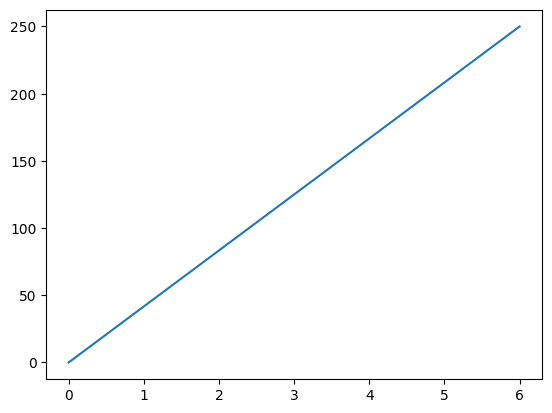

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

xpoints = np.array([0, 6])
ypoints = np.array([0, 250])

plt.plot(xpoints, ypoints)
plt.show()

In [5]:
from dataclasses import dataclass
from enum import Enum
import random
from typing import List


class PrescriptionLevel(Enum):
    LOW = 1
    MEDIUM = 2
    HIGH = 3


@dataclass
class Person:
    name: str
    wanted_prescriptions: list[str]


ASPIRIN = "Aspirin"
LISINOPRIL = "Lisinopril"
METFORMIN = "Metformin"
MORPHINE = "Morphine"
IBUPROFEN = "Ibuprofen"
ANTIBIOTIC = "Antibiotic"

DROGAS = [ASPIRIN, LISINOPRIL, METFORMIN, MORPHINE, IBUPROFEN, ANTIBIOTIC]


@dataclass
class Prescription:
    name: str
    level: PrescriptionLevel


def prescription_queue_algorithm() -> List[Prescription]:
    queues = {
        PrescriptionLevel.HIGH: [],
        PrescriptionLevel.MEDIUM: [],
        PrescriptionLevel.LOW: [],
    }

    people = [
        Person(
            name=f"Person_{i}",
            wanted_prescriptions=[
                drug for drug in DROGAS if random.random() > 0.5
            ],
        )
        for i in range(100)
    ]

    prescription_mapping = {
        ASPIRIN: PrescriptionLevel.LOW,
        IBUPROFEN: PrescriptionLevel.LOW,
        LISINOPRIL: PrescriptionLevel.MEDIUM,
        METFORMIN: PrescriptionLevel.MEDIUM,
        MORPHINE: PrescriptionLevel.HIGH,
        ANTIBIOTIC: PrescriptionLevel.HIGH,
    }

    for person in people:
        for prescription_name in person.wanted_prescriptions:
            level = prescription_mapping[prescription_name]
            queues[level].append(Prescription(prescription_name, level))

    filtered = []

    for level in [
        PrescriptionLevel.HIGH,
        PrescriptionLevel.MEDIUM,
        PrescriptionLevel.LOW,
    ]:
        for prescription in queues[level]:
            filtered.append(prescription)

    return filtered


if __name__ == "__main__":
    for a in prescription_queue_algorithm():
        print(a.name, a.level)


Morphine PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Morphine PrescriptionLevel.HIGH
Antibiotic PrescriptionLevel.HIGH
Morphine Pre

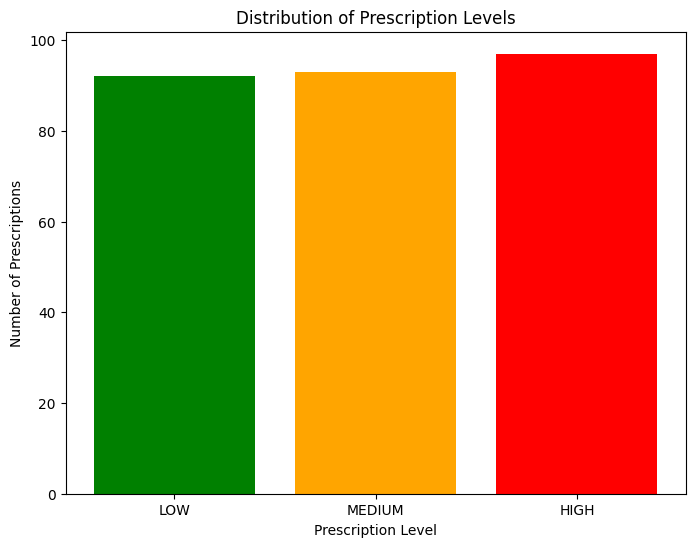

In [8]:
from collections import Counter
prescriptions = prescription_queue_algorithm()

levels = [p.level for p in prescriptions]
level_counts = Counter(levels)
level_names = [level.name for level in PrescriptionLevel]
counts = [level_counts[level] for level in PrescriptionLevel]

plt.figure(figsize=(8, 6))
plt.bar(level_names, counts, color=['green', 'orange', 'red'])
plt.xlabel('Prescription Level')
plt.ylabel('Number of Prescriptions')
plt.title('Distribution of Prescription Levels')
plt.show()